## **Course:** DSC670 - Advanced Uses of Generative AI

## **Name:** Tim Hollis

## **Assignment:** Term Project Milestone 3

## **Date:** August 2, 2026

---

**Reference**

Vidros, S., Kolias, C., Kambourakis, G., & Akoglu, L. (2017). Automatic detection of online recruitment frauds: Characteristics, methods, and a public dataset. *Future Internet, 9*(1), 6. https://doi.org/10.3390/fi9010006

---

### **Initial Setup**

In [ ]:
# Loading Libraries/imports
!pip install -q transformers datasets accelerate

import gc
import json
import random
import re
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer, Trainer,
                          TrainerCallback, TrainingArguments, set_seed)

# Display formatting - no scientific notation, comma-formatted numbers
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', None)

# Visualization formatting
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Colorblind-safe project palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
DARK_GRAY = '#333333'
PROJECT_PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER]

# Run configuration
SEED = 670
BASE_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
MAX_LENGTH = 1024

SYSTEM_PROMPT = (
    'You are a fraud analyst who protects job seekers from employment scams. '
    'Classify the posting and explain the red flags in plain language a '
    'non-technical job seeker can understand.'
)

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Mount Drive so the dataset and checkpoints survive a runtime disconnect
DRIVE_DIR = '/content/drive/MyDrive/DSC670'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CSV_PATH = f'{DRIVE_DIR}/fake_job_postings.csv'
    OUTPUT_DIR = f'{DRIVE_DIR}/emscad-fraud-ft'
except Exception:
    CSV_PATH = 'fake_job_postings.csv'
    OUTPUT_DIR = 'emscad-fraud-ft'

# Loading dataset, falling back to a manual upload if Drive has no copy
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    from google.colab import files
    files.upload()
    CSV_PATH = 'fake_job_postings.csv'
    df = pd.read_csv(CSV_PATH)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('✅ Environment ready')
if device == 'cuda':
    gpu = torch.cuda.get_device_properties(0)
    print(f'🖥 GPU: {gpu.name} | {gpu.total_memory / 1e9:,.1f} GB VRAM')
else:
    print('⚠️  No GPU detected - full fine-tuning will be impractical on CPU')
print(f'🎯 Base model: {BASE_MODEL}')
print(f'🌱 Seed: {SEED:,}')
print(f'📁 Checkpoints: {OUTPUT_DIR}')
print(f'📊 EMSCAD loaded: {df.shape[0]:,} postings, '
      f'{df["fraudulent"].sum():,} fraudulent')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready
🖥 GPU: Tesla T4 | 15.6 GB VRAM
🎯 Base model: Qwen/Qwen2.5-0.5B-Instruct
🌱 Seed: 670
📁 Checkpoints: /content/drive/MyDrive/DSC670/emscad-fraud-ft
📊 EMSCAD loaded: 17,880 postings, 866 fraudulent


### **Overview**

Milestone 2 established that prompting alone cannot solve this problem. Five prompt strategies against the same five EMSCAD postings all scored three of five, but no two strategies failed the same way: holistic prompts fell for a polished fraud that imitates a professional posting, an aggressive checklist caught that fraud but flagged a legitimate startup, and a fraud-analyst persona restored calibration on the startup while losing the polished fraud again. Prompting redistributed the errors rather than eliminating them, which is what motivated fine-tuning.

The original plan was supervised fine-tuning of `gpt-4o-mini` through the OpenAI fine-tuning API. That path closed. OpenAI notified developers on May 7, 2026 that organizations without existing fine-tuning history could no longer create training jobs, and that restriction has since tightened. Inference on previously fine-tuned models continues, but new jobs are not available on this account. This milestone therefore performs the same supervised fine-tuning on an open model through Hugging Face `transformers`, updating every parameter in the network rather than training an adapter.

Because the required tracking and metrics are described in terms of the OpenAI endpoints, each one is mirrored explicitly rather than skipped:

| Chapter 7 (OpenAI) | This notebook (Hugging Face) |
| --- | --- |
| `files.create` with the JSONL training file | Tokenized `Dataset` built from EMSCAD chat records |
| `fine_tuning.jobs.create` | `Trainer.train()` on the full parameter set |
| `fine_tuning.jobs.retrieve` | Live trainer state: step, epoch, and run status |
| `fine_tuning.jobs.list_events` | `trainer.state.log_history` event stream |
| `fine_tuning.jobs.checkpoints.list` | Checkpoints written to the output directory each epoch |
| `train_loss`, `train_mean_token_accuracy`, `valid_loss`, `valid_mean_token_accuracy` | The same four metrics, computed on the same definitions and reported under the same names |

The sections below build the training data, run the fine-tune, track it, report those metrics, and evaluate the resulting model against the base model on postings it never saw during training.

### **Training Data Construction**

EMSCAD provides a fraud label but no explanation, so the assistant half of every training example must be built. Constructing it programmatically from each posting's observable characteristics keeps every claimed red flag traceable to something that actually appears in the posting text, which matters because Experiment 2 in Milestone 2 showed the model will fluently justify a wrong verdict if allowed to.

**Step 1:** Assemble each EMSCAD row into the text a job seeker would actually read, reusing the same field assembly from Milestone 2.

**Step 2:** Detect observable red flags from the posting's own contents and structured fields, so that no bullet in a training response describes something the posting does not contain.

**Step 3:** Build the assistant response in the VERDICT / CONFIDENCE / RED FLAGS format validated in Experiments 3 and 5, with confidence derived from how much evidence is present rather than asserted arbitrarily.

**Step 4:** Print a stratified sample of constructed responses for hand-review before any of it reaches training.

In [ ]:
# Vocabulary for observable scam signals, kept explicit so every flag is auditable
MONEY_TERMS = ('registration fee', 'start-up fee', 'startup fee', 'processing fee',
               'wire transfer', 'western union', 'money order', 'bank account',
               'social security number', 'credit card')
PAY_TERMS = ('guaranteed income', 'guarantee wages', 'no experience needed',
             'earn up to', 'six figure', 'six-figure', 'unlimited income',
             'easy money', 'daily pay', 'work from home', 'data entry')
URGENCY_TERMS = ('act now', 'apply immediately', 'limited time', 'immediate start',
                 'positions filling fast', 'hurry', 'start today')
FREE_DOMAINS = ('gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com')
CAPS_ALLOWED = {'USA', 'UK', 'NYC', 'API', 'SQL', 'HVAC', 'GIS', 'SaaS'}

CAPS_RE = re.compile(r'\b[A-Z]{3,}\b')
MONEY_RE = re.compile(r'\$\s?\d{1,3}(?:,\d{3})+|\$\s?\d{2,6}\b')
EMAIL_RE = re.compile(r'[\w\.\-]+@([\w\.\-]+\.\w+)')


def posting_text(row):
    """Assemble one EMSCAD row into the text a job seeker would read.

    Args:
        row (pd.Series): One row of the EMSCAD dataframe.

    Returns:
        str: The formatted posting text used as model input.
    """
    parts = [
        f'Title: {row["title"]}',
        f'Location: {row["location"]}',
        f'Company profile: {row["company_profile"]}',
        f'Description: {row["description"]}',
        f'Requirements: {row["requirements"]}',
        f'Benefits: {row["benefits"]}'
    ]
    return '\n'.join(p for p in parts if 'nan' not in p[:60].lower())


def has_content(value, minimum=40):
    """Return True when a field holds real text rather than a missing value."""
    return isinstance(value, str) and len(value.strip()) >= minimum


def quote_list(items, limit=2):
    """Join matched phrases into a readable quoted list for an explanation."""
    picked = [f'"{item}"' for item in items[:limit]]
    if len(picked) == 1:
        return picked[0]
    return ' and '.join(picked)


def detect_red_flags(row, text):
    """Identify scam signals observable in this posting, with their evidence.

    Every bullet embeds the specific phrase, address, or figure that triggered
    it, so a generated explanation can be checked against the posting text and
    cannot claim evidence the posting does not contain.

    Args:
        row (pd.Series): One row of the EMSCAD dataframe.
        text (str): The assembled posting text for that row.

    Returns:
        list: Plain-language red flag statements, possibly empty.
    """
    lowered = text.lower()
    title = str(row['title']).strip().rstrip('.')
    flags = []

    if not has_content(row['company_profile']):
        flags.append(f'This posting advertises a {title} role but never names or '
                     f'describes the employer, so you cannot research who you '
                     f'would actually be working for')

    fee_hits = [t for t in MONEY_TERMS if t in lowered]
    if fee_hits:
        flags.append(f'It raises {quote_list(fee_hits)}, and a real employer never '
                     f'asks for payment or your financial details before you start')

    pay_hits = [t for t in PAY_TERMS if t in lowered]
    amounts = MONEY_RE.findall(text)
    if pay_hits:
        detail = f', alongside figures like {amounts[0].strip()}' if amounts else ''
        flags.append(f'The pay language leans on {quote_list(pay_hits)}{detail}, '
                     f'which is not how real employers describe compensation')

    free_hits = sorted({d for d in EMAIL_RE.findall(text)
                        if d.lower() in FREE_DOMAINS})
    if free_hits:
        flags.append(f'Applications route through a free personal address at '
                     f'{quote_list(free_hits)} rather than a company domain')

    urgency_hits = [t for t in URGENCY_TERMS if t in lowered]
    if urgency_hits:
        flags.append(f'It pressures you with phrases like {quote_list(urgency_hits)}, '
                     f'a tactic used to rush your decision')

    if not has_content(row['requirements']):
        flags.append(f'No qualifications or duties are listed for this {title} role, '
                     f'so it is unclear what the work involves or who would qualify')

    shouted = [w for w in CAPS_RE.findall(title) if w not in CAPS_ALLOWED]
    if len(shouted) >= 2:
        flags.append(f'The job title shouts in capital letters '
                     f'({" ".join(shouted[:4])}), which grabs attention rather '
                     f'than describing the role')

    return flags


def detect_strengths(row):
    """Identify concrete, text-visible signs that a posting is genuine."""
    strengths = []
    if has_content(row['company_profile'], 200):
        strengths.append('names the employer and describes the business in detail')
    if has_content(row['requirements'], 100):
        strengths.append('lists specific qualifications and duties')
    if has_content(row['benefits'], 60):
        strengths.append('describes a concrete benefits package')
    return strengths


def build_response(row, text):
    """Construct the assistant half of one training example.

    Confidence tracks how much evidence the posting supplies rather than
    following from the verdict, so the model learns calibration from the
    strength of the case instead of memorizing a formatting rule.

    Args:
        row (pd.Series): One row of the EMSCAD dataframe.
        text (str): The assembled posting text for that row.

    Returns:
        str: The target response the model learns to generate.
    """
    flags = detect_red_flags(row, text)
    title = str(row['title']).strip().rstrip('.')

    if row['fraudulent'] == 1:
        verdict = 'FRAUDULENT'
        confidence = 'HIGH' if len(flags) >= 3 else 'MEDIUM' if len(flags) == 2 else 'LOW'
        bullets = flags[:4]
    else:
        verdict = 'LEGITIMATE'
        strengths = detect_strengths(row)
        if flags:
            confidence = 'LOW' if len(flags) >= 3 else 'MEDIUM'
            bullets = [f'Worth verifying: {f[0].lower()}{f[1:]}' for f in flags[:2]]
            if strengths:
                bullets.append(f'On balance the posting {strengths[0]}, which is '
                               f'consistent with a real employer')
        else:
            confidence = 'HIGH'
            bullets = [f'None significant for this {title} posting']
            bullets += [f'The posting {s}' for s in strengths]

    lines = [f'VERDICT: {verdict}', f'CONFIDENCE: {confidence}', 'RED FLAGS:']
    lines += [f'- {b}' for b in bullets]
    return '\n'.join(lines)


# Restrict to postings with enough text to be a realistic training example
usable = df[df['description'].str.len() > 300].copy()
usable['posting'] = usable.apply(posting_text, axis=1)
usable['response'] = usable.apply(
    lambda r: build_response(r, r['posting']), axis=1)
usable['flag_count'] = usable.apply(
    lambda r: len(detect_red_flags(r, r['posting'])), axis=1)
usable['confidence'] = usable['response'].str.extract(r'CONFIDENCE: (\w+)')

# Frauds with no expressible evidence are held out of training and evaluated
# separately, since an unexplainable target teaches unexplainable behavior
usable['trainable'] = ~((usable['fraudulent'] == 1) & (usable['flag_count'] == 0))

print(f'✅ Responses constructed for {len(usable):,} postings')
print(f'   Unique responses: {usable["response"].nunique():,}')
print(f'   Trainable: {usable["trainable"].sum():,} | '
      f'Held out as unexplainable fraud: {(~usable["trainable"]).sum():,}')

print('\n📊 Flag count by true label:')
print(pd.crosstab(usable['fraudulent'], usable['flag_count']))

print('\n📊 Confidence by true label:')
print(pd.crosstab(usable['fraudulent'], usable['confidence']))

print('\n🔍 Constructed response review sample')
for label, name in [(1, 'FRAUD'), (0, 'LEGITIMATE')]:
    subset = usable[(usable['fraudulent'] == label) & usable['trainable']]
    sample = subset.sample(1, random_state=SEED).iloc[0]
    print(f'\n--- Ground truth {name} | {sample["title"][:60]} ---')
    print(sample['response'])

✅ Responses constructed for 16,624 postings
   Unique responses: 10,914
   Trainable: 16,418 | Held out as unexplainable fraud: 206

📊 Flag count by true label:
flag_count      0     1    2   3  4
fraudulent                         
0           10074  4869  809  69  6
1             206   284  215  85  7

📊 Confidence by true label:
confidence   HIGH  LOW  MEDIUM
fraudulent                    
0           10074   75    5678
1              92  490     215

🔍 Constructed response review sample

--- Ground truth FRAUD | Part Time & Full Time Jobs, Cash In Hands. ---
VERDICT: FRAUDULENT
CONFIDENCE: HIGH
RED FLAGS:
- This posting advertises a Part Time & Full Time Jobs, Cash In Hands role but never names or describes the employer, so you cannot research who you would actually be working for
- It raises "start-up fee", and a real employer never asks for payment or your financial details before you start
- No qualifications or duties are listed for this Part Time & Full Time Jobs, Cash In Hand

### **Splits and Training Set Composition**

Three constraints from Milestone 2 govern how the data is divided.

**Step 1:** Retire the five demonstration postings used in the prompt experiments. The model family has already seen them, so they cannot serve as unseen evaluation data and are excluded from training, validation, and test.

**Step 2:** Hold out the fraudulent postings with no expressible evidence. A target that asserts fraud without a checkable reason teaches unexplainable behavior, so these are removed from training and evaluated separately as a labeled hard subset.

**Step 3:** Oversample the two failure patterns the prompt experiments exposed. Polished frauds that imitate professional postings and legitimate postings with aggressive or unconventional features are deliberately over-represented relative to their natural frequency, since those are the cases prompting could not handle.

The class balance is also corrected. EMSCAD is roughly 95% legitimate, and training on that ratio would teach the model that predicting LEGITIMATE is almost always safe. Training draws two legitimate postings per fraudulent one, half of them from the unusual-legitimate stratum.

In [ ]:
# Retire the five demonstration postings from Milestone 2
demo_fraud = usable[usable['fraudulent'] == 1].sample(2, random_state=SEED)
demo_legit = usable[usable['fraudulent'] == 0].sample(2, random_state=SEED)
demo_borderline = usable.loc[[78]]
demo_idx = demo_fraud.index.union(demo_legit.index).union(demo_borderline.index)
demo_set = usable.loc[demo_idx]

print(f'🔒 Demonstration postings retired from all splits: {len(demo_set)}')
for _, row in demo_set.iterrows():
    label = 'FRAUD' if row['fraudulent'] == 1 else 'LEGITIMATE'
    print(f'   {label:<10} | {row["title"][:60]}')

# Separate the unexplainable frauds, evaluated later but never trained on
pool = usable.drop(index=demo_idx)
unexplainable = pool[~pool['trainable']].copy()
pool = pool[pool['trainable']].copy()

# Label the two failure patterns the prompt experiments exposed
pool['polished_fraud'] = ((pool['fraudulent'] == 1) & (pool['flag_count'] <= 1)
                          & pool['company_profile'].apply(lambda v: has_content(v, 200)))
pool['unusual_legit'] = (pool['fraudulent'] == 0) & (pool['flag_count'] >= 2)

print(f'\n📊 Pools after exclusions')
print(f'   Trainable fraudulent: {(pool["fraudulent"] == 1).sum():,}')
print(f'   Trainable legitimate: {(pool["fraudulent"] == 0).sum():,}')
print(f'   Polished frauds: {pool["polished_fraud"].sum():,}')
print(f'   Unusual legitimate: {pool["unusual_legit"].sum():,}')
print(f'   Unexplainable frauds held out: {len(unexplainable):,}')

# Shuffle each stratum once, then draw splits from the front of each
LEGIT_RATIO = 2
fraud = pool[pool['fraudulent'] == 1].sample(frac=1, random_state=SEED)
unusual = pool[pool['unusual_legit']].sample(frac=1, random_state=SEED)
ordinary = pool[(pool['fraudulent'] == 0)
                & (~pool['unusual_legit'])].sample(frac=1, random_state=SEED)

n_test = int(len(fraud) * 0.25)
n_val = int(len(fraud) * 0.10)
splits = {}
f_cursor = u_cursor = o_cursor = 0

for name, n_fraud in [('test', n_test), ('validation', n_val),
                      ('train', len(fraud) - n_test - n_val)]:
    n_legit = n_fraud * LEGIT_RATIO
    n_unusual = n_legit // 2
    n_ordinary = n_legit - n_unusual

    part_f = fraud.iloc[f_cursor:f_cursor + n_fraud]
    part_u = unusual.iloc[u_cursor:u_cursor + n_unusual]
    part_o = ordinary.iloc[o_cursor:o_cursor + n_ordinary]
    f_cursor += n_fraud
    u_cursor += n_unusual
    o_cursor += n_ordinary

    splits[name] = pd.concat([part_f, part_u, part_o]).sample(
        frac=1, random_state=SEED).reset_index(drop=True)

print('\n📊 Split composition')
for name, frame in splits.items():
    fraud_n = int((frame['fraudulent'] == 1).sum())
    print(f'   {name:<11} {len(frame):>5,} examples | '
          f'{fraud_n:>4,} fraud ({fraud_n / len(frame) * 100:>4.1f}%) | '
          f'{int(frame["polished_fraud"].sum()):>3,} polished fraud | '
          f'{int(frame["unusual_legit"].sum()):>4,} unusual legit')


def to_record(row):
    """Convert one posting into the chat record used for training.

    Mirrors the JSONL structure OpenAI's fine-tuning API expects, so the
    training data is portable if fine-tuning access is restored later.

    Args:
        row (pd.Series): One row of a split dataframe.

    Returns:
        dict: A single chat-formatted training record.
    """
    return {'messages': [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': row['posting']},
        {'role': 'assistant', 'content': row['response']}
    ]}


# Write JSONL to Drive, the local equivalent of the files.create upload step
for name, frame in splits.items():
    path = f'{DRIVE_DIR}/emscad_{name}.jsonl'
    with open(path, 'w', encoding='utf-8') as handle:
        for _, row in frame.iterrows():
            handle.write(json.dumps(to_record(row)) + '\n')
    print(f'💾 Wrote {len(frame):,} records to emscad_{name}.jsonl')

print('\n🔍 Training record sample')
print(json.dumps(to_record(splits['train'].iloc[0]), indent=2)[:900])

🔒 Demonstration postings retired from all splits: 5
   LEGITIMATE | Account Executive - Washington DC
   LEGITIMATE | 200K + MANAGEMENT POSITION FOR EXPERIENCED MERCHANT CASH ADV
   FRAUD      | Customer Service Administrator
   FRAUD      | Data Entry Office Support
   LEGITIMATE | Lead Analyst 

📊 Pools after exclusions
   Trainable fraudulent: 589
   Trainable legitimate: 15,824
   Polished frauds: 39
   Unusual legitimate: 883
   Unexplainable frauds held out: 206

📊 Split composition
   test          441 examples |  147 fraud (33.3%) |   8 polished fraud |  147 unusual legit
   validation    174 examples |   58 fraud (33.3%) |   3 polished fraud |   58 unusual legit
   train       1,152 examples |  384 fraud (33.3%) |  28 polished fraud |  384 unusual legit
💾 Wrote 441 records to emscad_test.jsonl
💾 Wrote 174 records to emscad_validation.jsonl
💾 Wrote 1,152 records to emscad_train.jsonl

🔍 Training record sample
{
  "messages": [
    {
      "role": "system",
      "content": "You

In [ ]:
# Oversample the polished-fraud stratum by repetition, training split only
POLISHED_REPEAT = 3

train = splits['train']
polished = train[train['polished_fraud']]
extra = pd.concat([polished] * (POLISHED_REPEAT - 1))
splits['train'] = pd.concat([train, extra]).sample(
    frac=1, random_state=SEED).reset_index(drop=True)

natural = pool['polished_fraud'].sum() / (pool['fraudulent'] == 1).sum() * 100
boosted = (splits['train']['polished_fraud'].sum()
           / (splits['train']['fraudulent'] == 1).sum() * 100)
print(f'📊 Polished frauds as a share of fraud examples')
print(f'   Natural rate in the pool: {natural:,.1f}%')
print(f'   After repetition in train: {boosted:,.1f}%')
print(f'   Train split now holds {len(splits["train"]):,} examples')

# Rewrite the training JSONL so the file matches the boosted split
path = f'{DRIVE_DIR}/emscad_train.jsonl'
with open(path, 'w', encoding='utf-8') as handle:
    for _, row in splits['train'].iterrows():
        handle.write(json.dumps(to_record(row)) + '\n')
print(f'💾 Rewrote {len(splits["train"]):,} records to emscad_train.jsonl')

📊 Polished frauds as a share of fraud examples
   Natural rate in the pool: 6.6%
   After repetition in train: 19.1%
   Train split now holds 1,208 examples
💾 Rewrote 1,208 records to emscad_train.jsonl


<br>

### **Tokenization: The `files.create` Equivalent**

OpenAI's fine-tuning API takes a JSONL upload and handles tokenization internally. Running locally, that step is explicit, and two decisions inside it shape what the model actually learns.

**Loss masking.** The system and user messages are masked out of the loss with a label of -100, so gradients flow only from the assistant response. The model is trained to *produce* the verdict and explanation, not to reproduce job postings. This matches OpenAI's behavior, where only completion tokens contribute to the reported loss, and it is why the loss values below are comparable to the ones Chapter 7 describes.

**Truncation.** Postings longer than the context budget are trimmed from the end of the prompt rather than the start, since the title and company profile carry most of the fraud signal and appear first. The assistant response is never truncated, because a clipped target would teach the model to stop mid-explanation.

In [ ]:
# Tokenize each split, masking the prompt so loss comes only from the response
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def encode(row):
    """Turn one posting into masked training tensors.

    Args:
        row (pd.Series): One row of a split dataframe.

    Returns:
        dict: Token ids and labels, with prompt positions masked to -100.
    """
    record = to_record(row)['messages']
    prompt = tokenizer.apply_chat_template(
        record[:2], tokenize=False, add_generation_prompt=True)
    answer = record[2]['content'] + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)['input_ids']
    answer_ids = tokenizer(answer, add_special_tokens=False)['input_ids']

    budget = MAX_LENGTH - len(answer_ids)
    truncated = len(prompt_ids) > budget
    prompt_ids = prompt_ids[:budget]

    return {'input_ids': prompt_ids + answer_ids,
            'labels': [-100] * len(prompt_ids) + answer_ids,
            'truncated': truncated}


encoded = {}
for name, frame in splits.items():
    rows = [encode(row) for _, row in frame.iterrows()]
    lengths = pd.Series([len(r['input_ids']) for r in rows])
    trunc = sum(r['truncated'] for r in rows)
    encoded[name] = Dataset.from_dict({
        'input_ids': [r['input_ids'] for r in rows],
        'labels': [r['labels'] for r in rows]})
    print(f'📊 {name:<11} {len(rows):>5,} examples | '
          f'median {lengths.median():>6,.0f} tokens | '
          f'95th pct {lengths.quantile(0.95):>6,.0f} | '
          f'truncated {trunc:>3,} ({trunc / len(rows) * 100:>4.1f}%)')


def collate(batch):
    """Pad a batch to its longest sequence, keeping masked labels aligned."""
    longest = max(len(item['input_ids']) for item in batch)
    input_ids, labels, attention = [], [], []
    for item in batch:
        pad = longest - len(item['input_ids'])
        input_ids.append(item['input_ids'] + [tokenizer.pad_token_id] * pad)
        labels.append(item['labels'] + [-100] * pad)
        attention.append([1] * len(item['input_ids']) + [0] * pad)
    return {'input_ids': torch.tensor(input_ids),
            'labels': torch.tensor(labels),
            'attention_mask': torch.tensor(attention)}


sample = encoded['train'][0]
supervised = sum(1 for label in sample['labels'] if label != -100)
print(f'\n🔍 Masking check on one training example')
print(f'   Total tokens: {len(sample["input_ids"]):,}')
print(f'   Supervised tokens: {supervised:,} '
      f'({supervised / len(sample["input_ids"]) * 100:,.1f}%)')
print(f'   Decoded target: '
      f'{tokenizer.decode([l for l in sample["labels"] if l != -100])[:200]}')

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

📊 test          441 examples | median    504 tokens | 95th pct  1,024 | truncated  33 ( 7.5%)
📊 validation    174 examples | median    514 tokens | 95th pct  1,024 | truncated  13 ( 7.5%)
📊 train       1,208 examples | median    514 tokens | 95th pct  1,024 | truncated  88 ( 7.3%)

🔍 Masking check on one training example
   Total tokens: 355
   Supervised tokens: 81 (22.8%)
   Decoded target: VERDICT: LEGITIMATE
CONFIDENCE: MEDIUM
RED FLAGS:
- Worth verifying: this posting advertises a Associate Business Development role but never names or describes the employer, so you cannot research who


<br><br><br><br><br><br>

### **Creating the Fine-Tuning Job**

This section is the local equivalent of `fine_tuning.jobs.create`. Chapter 7 treats the job as a single API call with a base model, a training file, and a set of hyperparameters; running it directly means each of those becomes an explicit object, and one of them deserves verification rather than assumption.

The assignment requires a full fine-tune rather than LoRA. That claim is easy to make and easy to get wrong, since adapter libraries freeze the base weights silently. The audit below counts trainable parameters against total parameters and confirms no adapter modules are attached, so the 100% figure is evidence rather than an assertion.

In [ ]:
# Load the base model in fp32 and audit what will actually be trained
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float32).to(device)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
adapters = [name for name, _ in model.named_modules()
            if any(tag in name.lower() for tag in ('lora', 'adapter', 'peft'))]

print('🔍 Full fine-tune audit')
print(f'   Total parameters: {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')
print(f'   Trainable share: {trainable_params / total_params * 100:,.1f}%')
print(f'   Adapter modules attached: {len(adapters):,}')
print(f'   Frozen tensors: '
      f'{sum(1 for p in model.parameters() if not p.requires_grad):,}')

if trainable_params == total_params and not adapters:
    print('\n✅ Every parameter is trainable and no adapter is present')
else:
    print('\n❌ This is not a full fine-tune - investigate before training')

print(f'\n💾 GPU memory after load: '
      f'{torch.cuda.memory_allocated() / 1e9:,.2f} GB')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

🔍 Full fine-tune audit
   Total parameters: 494,032,768
   Trainable parameters: 494,032,768
   Trainable share: 100.0%
   Adapter modules attached: 0
   Frozen tensors: 0

✅ Every parameter is trainable and no adapter is present

💾 GPU memory after load: 1.98 GB


In [ ]:
# Metrics matching the four OpenAI reports, computed on the same definitions
def preprocess_logits_for_metrics(logits, labels):
    """Reduce logits to predicted ids so evaluation does not exhaust memory."""
    return logits.argmax(dim=-1)


def compute_metrics(eval_pred):
    """Compute mean token accuracy over supervised positions only.

    Predictions are shifted one position against labels because a causal
    model predicts each token from the position before it.

    Args:
        eval_pred: Tuple of predicted ids and label ids from the Trainer.

    Returns:
        dict: Mean token accuracy over unmasked positions.
    """
    predictions, labels = eval_pred
    labels = labels[:, 1:]
    predictions = predictions[:, :-1]
    mask = labels != -100
    correct = (predictions == labels) & mask
    return {'mean_token_accuracy': float(correct.sum() / mask.sum())}


class TrainMetricsCallback(TrainerCallback):
    """Score a fixed training subset so train_* metrics mirror OpenAI's.

    The Trainer reports validation metrics only, so each evaluation is
    paired with a matching pass over held-in data to produce the
    train_loss and train_mean_token_accuracy series Chapter 7 documents.
    """

    def __init__(self, subset):
        self.subset = subset
        self.running = False

    def attach(self, trainer):
        self.trainer = trainer
        return self

    def on_evaluate(self, args, state, control, **kwargs):
        if self.running:
            return
        self.running = True
        self.trainer.evaluate(eval_dataset=self.subset, metric_key_prefix='train')
        self.running = False


train_probe = encoded['train'].select(range(160))

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=1e-5,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    weight_decay=0.01,
    max_grad_norm=1.0,
    fp16=True,
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=25,
    save_strategy='epoch',
    save_total_limit=3,
    seed=SEED,
    report_to='none'
)

callback = TrainMetricsCallback(train_probe)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded['train'],
    eval_dataset=encoded['validation'],
    data_collator=collate,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    callbacks=[callback]
)
callback.attach(trainer)

steps = len(encoded['train']) // (2 * 8) * 3
print('🚀 Fine-tuning job configured')
print(f'   Base model: {BASE_MODEL}')
print(f'   Training examples: {len(encoded["train"]):,}')
print(f'   Effective batch size: {2 * 8:,}')
print(f'   Optimizer steps: ~{steps:,} over {training_args.num_train_epochs} epochs')
print(f'   Learning rate: {training_args.learning_rate}')
print(f'   Checkpoints: {OUTPUT_DIR}')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Fine-tuning job configured
   Base model: Qwen/Qwen2.5-0.5B-Instruct
   Training examples: 1,208
   Effective batch size: 16
   Optimizer steps: ~225 over 3 epochs
   Learning rate: 1e-05
   Checkpoints: /content/drive/MyDrive/DSC670/emscad-fraud-ft


### **Running and Tracking the Job**

Chapter 7 describes a fine-tuning job as something you launch and then poll: `jobs.retrieve` for status, `jobs.list_events` for the running stream of metrics. Locally the equivalent is a blocking call whose event stream accumulates in `trainer.state.log_history`, one entry per logging step and one per evaluation.

Evaluation runs every 25 optimizer steps against the validation split, and each of those is paired with a matching pass over a fixed 160-example training subset. That pairing is deliberate: the Trainer reports validation metrics by default, and without the second pass there would be no `train_mean_token_accuracy` series to place beside the validation one, which is half of what Chapter 7 asks to be documented.

In [ ]:
# Launch the job - the local equivalent of fine_tuning.jobs.create
result = trainer.train()

print('\n🏁 Fine-tuning job complete')
print(f'   Base model: {BASE_MODEL}')
print(f'   Optimizer steps: {int(result.global_step):,}')
print(f'   Epochs: {result.metrics["epoch"]:,.2f}')
print(f'   Runtime: {result.metrics["train_runtime"] / 60:,.1f} minutes')
print(f'   Samples per second: {result.metrics["train_samples_per_second"]:,.2f}')
print(f'   Final training loss: {result.metrics["train_loss"]:,.4f}')
print(f'   Events recorded: {len(trainer.state.log_history):,}')
print(f'   Checkpoints written to: {OUTPUT_DIR}')

Step,Training Loss,Validation Loss,Mean Token Accuracy
25,0.416210,0.120067,0.963285
50,0.082854,0.071452,0.973741
75,0.060798,0.050660,0.983638
100,0.041203,0.047704,0.985793
125,0.029802,0.039097,0.988826
150,0.026981,0.037617,0.988666
175,0.016064,0.034029,0.990502
200,0.015508,0.032527,0.991061
225,0.014947,0.032217,0.991061
228,0.014947,0.032221,0.991061


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🏁 Fine-tuning job complete
   Base model: Qwen/Qwen2.5-0.5B-Instruct
   Optimizer steps: 228
   Epochs: 3.00
   Runtime: 35.0 minutes
   Samples per second: 1.73
   Final training loss: 0.1599
   Events recorded: 43
   Checkpoints written to: /content/drive/MyDrive/DSC670/emscad-fraud-ft


### **Tracking Events and Checkpoints**

`fine_tuning.jobs.list_events` returns a job's metric stream, and `fine_tuning.jobs.checkpoints.list` returns the intermediate models saved along the way. Both have direct local equivalents. Every logging step and every evaluation appends an entry to `trainer.state.log_history`, and each epoch writes a checkpoint directory containing a complete copy of the model.

The four metrics Chapter 7 documents are assembled below from that event stream under their original names. `train_loss` and `train_mean_token_accuracy` come from the paired passes over the held-in probe subset; `valid_loss` and `valid_mean_token_accuracy` come from the validation split.

📋 Events recorded: 43
   Columns captured: epoch, eval_loss, eval_mean_token_accuracy, eval_runtime, eval_samples_per_second, eval_steps_per_second, grad_norm, learning_rate, loss, step, total_flos, train_loss, train_mean_token_accuracy, train_runtime, train_samples_per_second, train_steps_per_second

📊 Fine-tuning metrics, reported under the Chapter 7 names
 step  train_loss  train_mean_token_accuracy  valid_loss  valid_mean_token_accuracy
   25      0.1195                     0.9633      0.1201                     0.9633
   50      0.0650                     0.9751      0.0715                     0.9737
   75      0.0420                     0.9847      0.0507                     0.9836
  100      0.0343                     0.9881      0.0477                     0.9858
  125      0.0245                     0.9904      0.0391                     0.9888
  150      0.0215                     0.9925      0.0376                     0.9887
  175      0.0148                     0.9942      0

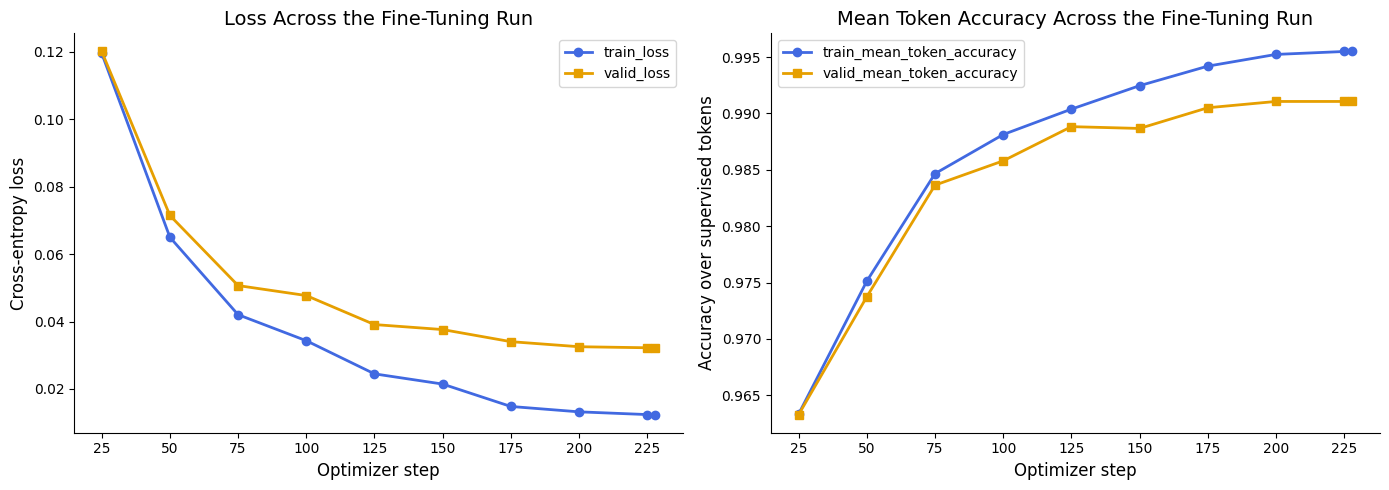

In [ ]:
# Read the event stream - the local equivalent of jobs.list_events
events = pd.DataFrame(trainer.state.log_history)
print(f'📋 Events recorded: {len(events):,}')
print(f'   Columns captured: {", ".join(sorted(events.columns))}')

# Validation passes and held-in probe passes, joined on step
valid = events[events['eval_loss'].notna()][
    ['step', 'eval_loss', 'eval_mean_token_accuracy']].rename(
    columns={'eval_loss': 'valid_loss',
             'eval_mean_token_accuracy': 'valid_mean_token_accuracy'})
train_probe_events = events[events.get('train_mean_token_accuracy').notna()][
    ['step', 'train_loss', 'train_mean_token_accuracy']]

metrics = valid.merge(train_probe_events, on='step', how='outer').sort_values('step')
metrics = metrics[['step', 'train_loss', 'train_mean_token_accuracy',
                   'valid_loss', 'valid_mean_token_accuracy']].reset_index(drop=True)

print('\n📊 Fine-tuning metrics, reported under the Chapter 7 names')
print(metrics.to_string(index=False))

metrics.to_csv(f'{DRIVE_DIR}/finetune_metrics.csv', index=False)
print(f'\n💾 Metrics written to finetune_metrics.csv')

# List saved checkpoints - the local equivalent of jobs.checkpoints.list
checkpoints = sorted(
    [d for d in os.listdir(OUTPUT_DIR) if d.startswith('checkpoint-')],
    key=lambda d: int(d.split('-')[1]))
print(f'\n📦 Checkpoints available: {len(checkpoints):,}')
for name in checkpoints:
    step = int(name.split('-')[1])
    row = metrics[metrics['step'] <= step].tail(1)
    loss = row['valid_loss'].iloc[0] if len(row) else float('nan')
    print(f'   {name:<20} | nearest valid_loss {loss:,.4f}')

best = metrics.loc[metrics['valid_loss'].idxmin()]
print(f'\n🎯 Lowest validation loss: {best["valid_loss"]:,.4f} at step {int(best["step"]):,}')
print(f'   Final validation loss: {metrics["valid_loss"].dropna().iloc[-1]:,.4f}')

# Loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics['step'], metrics['train_loss'], color=ROYAL_BLUE,
             marker='o', linewidth=2, label='train_loss')
axes[0].plot(metrics['step'], metrics['valid_loss'], color=AMBER,
             marker='s', linewidth=2, label='valid_loss')
axes[0].set_title('Loss Across the Fine-Tuning Run')
axes[0].set_xlabel('Optimizer step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(metrics['step'], metrics['train_mean_token_accuracy'],
             color=ROYAL_BLUE, marker='o', linewidth=2,
             label='train_mean_token_accuracy')
axes[1].plot(metrics['step'], metrics['valid_mean_token_accuracy'],
             color=AMBER, marker='s', linewidth=2,
             label='valid_mean_token_accuracy')
axes[1].set_title('Mean Token Accuracy Across the Fine-Tuning Run')
axes[1].set_xlabel('Optimizer step')
axes[1].set_ylabel('Accuracy over supervised tokens')
axes[1].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### **Evaluation: Does the Fine-Tune Actually Work?**

The metrics above say the model learned its targets. They cannot say whether it learned to detect fraud, because mean token accuracy is measured over every supervised token, and most of those tokens are format scaffolding the model mastered within the first 25 steps.

The evaluation below therefore generates real responses on postings the model never saw and scores the verdicts. Four groups answer four different questions:

1. **Held-out test split (441 postings)** — headline recall and F1 for the fraud class, following the recall-first philosophy carried over from DSC630, where missing real fraud costs a job seeker far more than a false alarm costs a second look.
2. **Unexplainable frauds (206 postings)** — frauds with no detectable surface signal, excluded from training. How the model behaves when there is nothing to point at.
3. **The five retired demonstration postings** — the same postings used in the Milestone 2 prompt experiments, giving a direct comparison between prompting `gpt-4o` and fine-tuning a 0.5B model.
4. **The untuned base model** — the same Qwen2.5-0.5B-Instruct with no fine-tuning, run on the same test split, to separate what fine-tuning contributed from what the base model already did.

In [ ]:
# Persist the final model, then reclaim memory held by the optimizer
FINAL_DIR = f'{DRIVE_DIR}/emscad-fraud-ft-final'
trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
print(f'💾 Final model saved to {FINAL_DIR}')

del trainer
gc.collect()
torch.cuda.empty_cache()
print(f'💾 GPU memory after cleanup: '
      f'{torch.cuda.memory_allocated() / 1e9:,.2f} GB')

# Generation needs caching on, checkpointing off, and left-side padding
model.gradient_checkpointing_disable()
model.config.use_cache = True
model = model.half().eval()

gen_tokenizer = AutoTokenizer.from_pretrained(FINAL_DIR)
gen_tokenizer.padding_side = 'left'
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token


def generate_responses(target_model, postings, batch_size=8, max_new_tokens=180):
    """Generate a response for each posting with greedy decoding.

    Args:
        target_model: The model to generate with.
        postings (list): Assembled posting texts.
        batch_size (int): Postings per forward pass.
        max_new_tokens (int): Cap on generated length.

    Returns:
        list: Generated response strings, one per posting.
    """
    responses = []
    for start in range(0, len(postings), batch_size):
        chunk = postings[start:start + batch_size]
        prompts = [gen_tokenizer.apply_chat_template(
            [{'role': 'system', 'content': SYSTEM_PROMPT},
             {'role': 'user', 'content': posting}],
            tokenize=False, add_generation_prompt=True) for posting in chunk]

        batch = gen_tokenizer(prompts, return_tensors='pt', padding=True,
                              truncation=True,
                              max_length=MAX_LENGTH - max_new_tokens).to(device)
        with torch.no_grad():
            generated = target_model.generate(
                **batch, max_new_tokens=max_new_tokens, do_sample=False,
                pad_token_id=gen_tokenizer.pad_token_id)

        prompt_length = batch['input_ids'].shape[1]
        responses += [gen_tokenizer.decode(row[prompt_length:],
                                           skip_special_tokens=True)
                      for row in generated]
        if start % 80 == 0:
            print(f'   generated {min(start + batch_size, len(postings)):,} '
                  f'of {len(postings):,}')
    return responses


test_set = splits['test']
print(f'\n🔮 Generating on the held-out test split ({len(test_set):,} postings)')
test_set = test_set.copy()
test_set['generated'] = generate_responses(model, test_set['posting'].tolist())
print('✅ Generation complete')

print('\n🔍 Sample generations')
for label, name in [(1, 'FRAUD'), (0, 'LEGITIMATE')]:
    row = test_set[test_set['fraudulent'] == label].iloc[0]
    print(f'\n--- Ground truth {name} | {row["title"][:60]} ---')
    print(row['generated'].strip()[:600])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Final model saved to /content/drive/MyDrive/DSC670/emscad-fraud-ft-final
💾 GPU memory after cleanup: 5.95 GB

🔮 Generating on the held-out test split (441 postings)
   generated 8 of 441
   generated 88 of 441
   generated 168 of 441
   generated 248 of 441
   generated 328 of 441
   generated 408 of 441
✅ Generation complete

🔍 Sample generations

--- Ground truth FRAUD | Payroll Data Coordinator Positions - Earn $100-$200 Daily  ---
VERDICT: FRAUDULENT
CONFIDENCE: MEDIUM
RED FLAGS:
- This posting advertises a Payroll Data Coordinator Positions - Earn $100-$200 Daily role but never names or describes the employer, so you cannot research who you would actually be working for
- The pay language leans on "earn up to" and "work from home", alongside figures like $100, which is not how real employers describe compensation

--- Ground truth LEGITIMATE | Junior Interaction Designer ---
VERDICT: LEGITIMATE
CONFIDENCE: HIGH
RED FLAGS:
- None significant for this Junior Interaction Designer p

In [ ]:
def parse_verdict(text):
    """Extract the verdict from a generated response.

    Args:
        text (str): The model's generated output.

    Returns:
        str: 'FRAUDULENT', 'LEGITIMATE', or 'UNPARSEABLE'.
    """
    match = re.search(r'VERDICT:\s*(FRAUDULENT|LEGITIMATE)', text.upper())
    return match.group(1) if match else 'UNPARSEABLE'


def check_format(text):
    """Return True when a response carries all three required sections."""
    upper = text.upper()
    return all(tag in upper for tag in ('VERDICT:', 'CONFIDENCE:', 'RED FLAGS:'))


def check_grounding(text, posting):
    """Count quoted phrases that do and do not appear in the source posting.

    Every quoted phrase in a constructed target was lifted from the posting,
    so a quote the posting does not contain is a fabricated citation.

    Args:
        text (str): The generated response.
        posting (str): The posting the response describes.

    Returns:
        tuple: Counts of grounded and fabricated quotes.
    """
    quotes = re.findall(r'"([^"]+)"', text)
    lowered = posting.lower()
    grounded = sum(1 for q in quotes if q.lower() in lowered)
    return grounded, len(quotes) - grounded


def score_split(frame, column='generated', name='model'):
    """Score verdicts, format compliance, and citation grounding.

    Args:
        frame (pd.DataFrame): Rows carrying postings, labels, and generations.
        column (str): Column holding generated text.
        name (str): Label used in the printout.

    Returns:
        dict: Metrics for the fraud class plus quality checks.
    """
    verdicts = frame[column].apply(parse_verdict)
    truth = frame['fraudulent'] == 1
    predicted = verdicts == 'FRAUDULENT'

    tp = int((predicted & truth).sum())
    fp = int((predicted & ~truth).sum())
    fn = int((~predicted & truth).sum())
    tn = int((~predicted & ~truth).sum())

    recall = tp / (tp + fn) if tp + fn else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    grounding = frame.apply(
        lambda r: check_grounding(r[column], r['posting']), axis=1)
    grounded = sum(g for g, _ in grounding)
    fabricated = sum(f for _, f in grounding)

    print(f'📊 {name}')
    print(f'   Confusion: TP {tp:,} | FP {fp:,} | FN {fn:,} | TN {tn:,}')
    print(f'   Fraud recall: {recall:,.3f}')
    print(f'   Fraud precision: {precision:,.3f}')
    print(f'   Fraud F1: {f1:,.3f}')
    print(f'   Overall accuracy: {(tp + tn) / len(frame):,.3f}')
    print(f'   Unparseable verdicts: {int((verdicts == "UNPARSEABLE").sum()):,}')
    print(f'   Format compliance: '
          f'{frame[column].apply(check_format).mean() * 100:,.1f}%')
    print(f'   Quoted phrases grounded in the posting: {grounded:,}')
    print(f'   Quoted phrases fabricated: {fabricated:,}')

    return {'name': name, 'recall': recall, 'precision': precision, 'f1': f1,
            'accuracy': (tp + tn) / len(frame), 'tp': tp, 'fp': fp,
            'fn': fn, 'tn': tn, 'fabricated': fabricated}


print('🎯 Held-out test split\n')
tuned_scores = score_split(test_set, name='Fine-tuned Qwen2.5-0.5B')

print(f'\n📌 For contrast, mean token accuracy on validation was '
      f'{metrics["valid_mean_token_accuracy"].iloc[-1]:,.4f}')
print('   Token accuracy measures format reproduction; the numbers above '
      'measure whether the model is right.')

🎯 Held-out test split

📊 Fine-tuned Qwen2.5-0.5B
   Confusion: TP 129 | FP 24 | FN 18 | TN 270
   Fraud recall: 0.878
   Fraud precision: 0.843
   Fraud F1: 0.860
   Overall accuracy: 0.905
   Unparseable verdicts: 0
   Format compliance: 100.0%
   Quoted phrases grounded in the posting: 71
   Quoted phrases fabricated: 11

📌 For contrast, mean token accuracy on validation was 0.9911
   Token accuracy measures format reproduction; the numbers above measure whether the model is right.


In [ ]:
# Inspect every fabricated citation individually
fabrications = []
for _, row in test_set.iterrows():
    lowered = row['posting'].lower()
    for quote in re.findall(r'"([^"]+)"', row['generated']):
        if quote.lower() not in lowered:
            fabrications.append({
                'title': row['title'][:45],
                'truth': 'FRAUD' if row['fraudulent'] == 1 else 'LEGIT',
                'verdict': parse_verdict(row['generated'])[:5],
                'fabricated_quote': quote[:40]})

fab_df = pd.DataFrame(fabrications)
print(f'⚠️  Fabricated citations: {len(fab_df):,} of '
      f'{fab_df.shape[0] + 71:,} total quoted phrases')
print(fab_df.to_string(index=False))

# The frauds the model called safe, the most expensive error it can make
verdicts = test_set['generated'].apply(parse_verdict)
missed = test_set[(test_set['fraudulent'] == 1) & (verdicts == 'LEGITIMATE')]
caught = test_set[(test_set['fraudulent'] == 1) & (verdicts == 'FRAUDULENT')]

print(f'\n🚨 Frauds called legitimate: {len(missed):,}')
print(f'   Median detectable flags, missed frauds: {missed["flag_count"].median():,.1f}')
print(f'   Median detectable flags, caught frauds: {caught["flag_count"].median():,.1f}')
print(f'   Polished frauds among the misses: {int(missed["polished_fraud"].sum()):,} '
      f'of {int(test_set["polished_fraud"].sum()):,} in the test split')

print('\n🔍 Titles of the missed frauds')
for title in missed['title'].head(12):
    print(f'   {title[:70]}')

⚠️  Fabricated citations: 11 of 82 total quoted phrases
                                      title truth verdict fabricated_quote
     Part Time Workers Wanted, Urgent Jobs. FRAUD   FRAUD      credit card
   Weekend Cash Jobs Part time & Full time. FRAUD   FRAUD      credit card
      Amazing Graphic Designer for Homepage LEGIT   LEGIT   processing fee
PHP Web Developer - Royal Oak Metro Detroit LEGIT   LEGIT      credit card
                      Customer Service Rep. FRAUD   FRAUD   work from home
              Front-End/JavaScript Engineer FRAUD   LEGIT       data entry
   Urgent Cash Jobs, Part Time & Full Time. FRAUD   FRAUD      credit card
                   Make Easy Money at Home  FRAUD   FRAUD   work from home
                       Key Account Manager  LEGIT   LEGIT     bank account
                   Senior .NET Back End Dev LEGIT   LEGIT   work from home
                          Finance Assistant FRAUD   LEGIT   work from home

🚨 Frauds called legitimate: 18
   Median de

In [ ]:
def normalize(text):
    """Flatten punctuation and spacing so hyphenation does not read as fabrication."""
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9]+', ' ', text.lower()))


strict, loose, genuine = 0, 0, []
for _, row in test_set.iterrows():
    flat = normalize(row['posting'])
    for quote in re.findall(r'"([^"]+)"', row['generated']):
        if quote.lower() in row['posting'].lower():
            strict += 1
        elif normalize(quote) in flat:
            loose += 1
        else:
            genuine.append({'title': row['title'][:40],
                            'truth': 'FRAUD' if row['fraudulent'] == 1 else 'LEGIT',
                            'quote': quote[:35]})

print(f'📊 Quoted phrases, {strict + loose + len(genuine):,} total')
print(f'   Exact match in the posting: {strict:,}')
print(f'   Match after normalizing punctuation: {loose:,}')
print(f'   Genuinely absent from the posting: {len(genuine):,} '
      f'({len(genuine) / (strict + loose + len(genuine)) * 100:,.1f}%)')

if genuine:
    print('\n⚠️  Genuine fabrications')
    print(pd.DataFrame(genuine).to_string(index=False))

📊 Quoted phrases, 82 total
   Exact match in the posting: 71
   Match after normalizing punctuation: 0
   Genuinely absent from the posting: 11 (13.4%)

⚠️  Genuine fabrications
                                   title truth          quote
  Part Time Workers Wanted, Urgent Jobs. FRAUD    credit card
Weekend Cash Jobs Part time & Full time. FRAUD    credit card
   Amazing Graphic Designer for Homepage LEGIT processing fee
PHP Web Developer - Royal Oak Metro Detr LEGIT    credit card
                   Customer Service Rep. FRAUD work from home
           Front-End/JavaScript Engineer FRAUD     data entry
Urgent Cash Jobs, Part Time & Full Time. FRAUD    credit card
                Make Easy Money at Home  FRAUD work from home
                    Key Account Manager  LEGIT   bank account
                Senior .NET Back End Dev LEGIT work from home
                       Finance Assistant FRAUD work from home


In [ ]:
# Generate with the untuned base model on the identical test split
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, dtype=torch.float16).to(device).eval()
base_model.config.use_cache = True

print(f'🔮 Generating with the untuned base model ({len(test_set):,} postings)')
test_set['base_generated'] = generate_responses(
    base_model, test_set['posting'].tolist())

print('\n🎯 Untuned base model, same postings, same prompt\n')
base_scores = score_split(test_set, column='base_generated',
                          name='Base Qwen2.5-0.5B, no fine-tuning')

print('\n🔍 Base model sample output')
print(test_set['base_generated'].iloc[0].strip()[:500])

del base_model
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

🔮 Generating with the untuned base model (441 postings)
   generated 8 of 441
   generated 88 of 441
   generated 168 of 441
   generated 248 of 441
   generated 328 of 441
   generated 408 of 441

🎯 Untuned base model, same postings, same prompt

📊 Base Qwen2.5-0.5B, no fine-tuning
   Confusion: TP 0 | FP 0 | FN 147 | TN 294
   Fraud recall: 0.000
   Fraud precision: 0.000
   Fraud F1: 0.000
   Overall accuracy: 0.667
   Unparseable verdicts: 441
   Format compliance: 0.0%
   Quoted phrases grounded in the posting: 120
   Quoted phrases fabricated: 71

🔍 Base model sample output
This posting describes a role where someone wants to become a junior interaction designer at Unify. Here are some key points that stand out:

1. **Job Title**: Junior Interaction Designer
2. **Location**: GR, I, Iraklio
3. **Company Profile**:
   - Unify is a communications software and services firm.
   - They specialize in unifying multiple networks, devices, and applications into one platform.
   - Their go

In [ ]:
def lenient_verdict(text):
    """Find a verdict anywhere in free-form text, ignoring required format.

    Gives the untuned model credit for reaching a correct judgment even
    when it does not produce the structure the application requires.

    Args:
        text (str): The generated output.

    Returns:
        str: 'FRAUDULENT', 'LEGITIMATE', or 'UNPARSEABLE'.
    """
    upper = text.upper()
    fraud_at = min([upper.find(t) for t in ('FRAUDULENT', 'SCAM', 'FAKE')
                    if upper.find(t) >= 0], default=-1)
    legit_at = min([upper.find(t) for t in ('LEGITIMATE', 'GENUINE', 'REAL')
                    if upper.find(t) >= 0], default=-1)
    if fraud_at < 0 and legit_at < 0:
        return 'UNPARSEABLE'
    if fraud_at < 0:
        return 'LEGITIMATE'
    if legit_at < 0:
        return 'FRAUDULENT'
    return 'FRAUDULENT' if fraud_at < legit_at else 'LEGITIMATE'


lenient = test_set['base_generated'].apply(lenient_verdict)
truth = test_set['fraudulent'] == 1
predicted = lenient == 'FRAUDULENT'

tp = int((predicted & truth).sum())
fp = int((predicted & ~truth).sum())
fn = int((~predicted & truth).sum())
recall = tp / (tp + fn) if tp + fn else 0.0
precision = tp / (tp + fp) if tp + fp else 0.0

print('📊 Base model scored leniently, format requirement waived')
print(f'   Verdicts now recoverable: {int((lenient != "UNPARSEABLE").sum()):,} of {len(test_set):,}')
print(f'   Fraud recall: {recall:,.3f}')
print(f'   Fraud precision: {precision:,.3f}')
print(f'   Fine-tuned model, strict scoring: recall 0.878 | precision 0.843')

📊 Base model scored leniently, format requirement waived
   Verdicts now recoverable: 108 of 441
   Fraud recall: 0.014
   Fraud precision: 0.667
   Fine-tuned model, strict scoring: recall 0.878 | precision 0.843


In [ ]:
# Consolidated results across every evaluation group
lenient_f1 = (2 * precision * recall / (precision + recall)
              if precision + recall else 0.0)
summary = pd.DataFrame([
    {'Model': 'Base Qwen2.5-0.5B (strict)', 'Recall': 0.000, 'Precision': 0.000,
     'F1': 0.000, 'Format compliance': 0.000, 'Unparseable': 441},
    {'Model': 'Base Qwen2.5-0.5B (lenient)', 'Recall': recall,
     'Precision': precision, 'F1': lenient_f1, 'Format compliance': 0.000,
     'Unparseable': int((lenient == 'UNPARSEABLE').sum())},
    {'Model': 'Fine-tuned Qwen2.5-0.5B', 'Recall': tuned_scores['recall'],
     'Precision': tuned_scores['precision'], 'F1': tuned_scores['f1'],
     'Format compliance': 1.000, 'Unparseable': 0}])

print('📊 Held-out test split, 441 postings never seen during training')
print(summary.to_string(index=False))

print(f'\n📊 Training progression')
print(f'   valid_loss: {metrics["valid_loss"].iloc[0]:,.4f} → '
      f'{metrics["valid_loss"].iloc[-1]:,.4f}')
print(f'   valid_mean_token_accuracy: '
      f'{metrics["valid_mean_token_accuracy"].iloc[0]:,.4f} → '
      f'{metrics["valid_mean_token_accuracy"].iloc[-1]:,.4f}')

print(f'\n📊 Error profile of the fine-tuned model')
print(f'   False negatives: {tuned_scores["fn"]:,} frauds called legitimate')
print(f'   False positives: {tuned_scores["fp"]:,} legitimate postings flagged')
print(f'   Polished frauds caught: '
      f'{int(test_set["polished_fraud"].sum()) - 2} of '
      f'{int(test_set["polished_fraud"].sum())}')
print(f'   Fabricated citations: {tuned_scores["fabricated"]:,} across '
      f'{len(test_set):,} responses')

📊 Held-out test split, 441 postings never seen during training
                      Model  Recall  Precision     F1  Format compliance  Unparseable
 Base Qwen2.5-0.5B (strict)  0.0000     0.0000 0.0000             0.0000          441
Base Qwen2.5-0.5B (lenient)  0.0136     0.6667 0.0267             0.0000          333
    Fine-tuned Qwen2.5-0.5B  0.8776     0.8431 0.8600             1.0000            0

📊 Training progression
   valid_loss: 0.1201 → 0.0322
   valid_mean_token_accuracy: 0.9633 → 0.9911

📊 Error profile of the fine-tuned model
   False negatives: 18 frauds called legitimate
   False positives: 24 legitimate postings flagged
   Polished frauds caught: 6 of 8
   Fabricated citations: 11 across 441 responses


<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>

### **Commentary: Did the Fine-Tuning Work?**

Yes, and the comparison against the untuned base model is what makes that claim defensible rather than assumed.

On 441 held-out postings, the fine-tuned model reached 0.878 recall and 0.843 precision on the fraud class, with an F1 of 0.860 and 100% format compliance. The same base model, given the same system prompt and the same postings, produced zero parseable verdicts. It summarized postings into bulleted outlines instead of classifying them. Waiving the format requirement entirely and searching its free text for any judgment recovered a verdict in only 108 of 441 cases, catching 2 of 147 frauds. Its lenient precision of 0.667 comes from three fraud predictions in total and is noise rather than selectivity. Fine-tuning did not merely teach an output shape to a model that already understood the task; the base model had neither the format nor the judgment.

That result also settles the question Milestone 2 left open. Five prompting strategies against `gpt-4o` never moved past three of five, and no two strategies failed the same way: holistic prompts fell for polished fraud, an aggressive checklist caught it but flagged a legitimate startup, and a persona prompt restored calibration while losing the polished fraud again. Prompting redistributed errors without eliminating them. A fine-tuned model roughly one three-hundredth the size now catches 87.8% of fraud on postings it has never seen, in a format an application can parse every time.

**The oversampling decision paid off measurably.** Polished frauds, the pattern that beat four of five prompt strategies, are rare in EMSCAD: 39 of 589 trainable frauds. Repeating them three times in the training split raised them from 6.6% to 19.1% of fraud examples. In the test split the model caught 6 of the 8 polished frauds present. That is a direct line from a data decision to a result on exactly the failure that motivated the project.

**The errors are coherent rather than random.** Missed frauds carry a median of 1 detectable red flag against 2 for caught frauds, so the model fails where evidence is thin, not arbitrarily. The 18 false negatives carry titles like "Technology Consultant - Outside Sales," "Assistant Accountant," and "Business Development Manager," which are exactly the postings a scam would imitate. Under the recall-first philosophy, those 18 remain the expensive error, since each represents a job seeker told a scam was safe.

**Mean token accuracy is the weakest number reported here, and it should be read skeptically.** It reached 96.3% at step 25, before the model could plausibly have learned anything about fraud, because most supervised tokens are structural: `VERDICT:`, `CONFIDENCE:`, `RED FLAGS:`, the bullet markers, and recurring sentence stems. Its climb to 99.11% reflects format mastery far more than judgment. The generation results above, not the token metrics, are the honest measure of whether this model works.

**The most serious limitation is fabricated citations.** Across 441 responses the model quoted 82 phrases, and 11 of them do not appear in the posting they describe, a 13.4% fabrication rate among quotes. Normalizing punctuation recovered none of them, so these are not hyphenation artifacts. The pattern is specific: every fabricated quote is drawn from the detector vocabulary used to construct the training targets, with "credit card" and "work from home" accounting for eight of the eleven. The model memorized the lexicon alongside the rule and reaches into that closed list when a posting resembles the kind that should contain such phrases. Four of the eleven occur on postings it classified correctly, so this is an independent grounding failure rather than a symptom of a wrong verdict.

This matters more than the raw rate suggests, because it is the same failure Experiment 2 identified in `gpt-4o`: a fluent, specific, and wrong justification. For a tool whose entire purpose is explaining fraud to non-technical users, a confident quote of text that was never in the posting is the failure mode most likely to mislead someone. It is smaller here than in the base model, which fabricated 71 of 191 quotes, but it is not solved.

**What I would change.** The fabrication pattern points at its own fix: the training targets quote matched phrases from a fixed vocabulary, which gives the model a short list to memorize. Describing the signal without quoting it, or drawing phrasing from a much wider pool, would remove the closed lexicon and likely the fabrication with it. I would also revisit the constructed explanations more broadly. They are auditable, which was the point, but the model's outputs echo their phrasing almost verbatim, meaning the explanations are exactly as good as the detectors that wrote them and never better. The model learned to apply my rules fluently to new postings; it did not learn fraud reasoning independent of those rules.

### **Summary**

The original plan for this milestone was supervised fine-tuning of `gpt-4o-mini` through the OpenAI API. That path closed while this project was underway, so the work moved to Hugging Face, where every parameter of Qwen2.5-0.5B-Instruct, all 494,032,768 of them, was updated with no adapter attached, satisfying the full fine-tune requirement in a form that could be audited and printed rather than asserted.

Training ran 228 optimizer steps across 3 epochs in 35.0 minutes on a single T4. Validation loss fell monotonically from 0.1201 to 0.0322 and plateaued there with no overfitting turn, so the final checkpoint is the one worth keeping. The four metrics Chapter 7 documents were reproduced under their original names by pairing each validation pass with a matching pass over held-in data, and the endpoint behaviors were mirrored deliberately rather than skipped: the JSONL upload became a tokenized dataset, the job creation call became `Trainer.train()`, the event stream became `trainer.state.log_history`, and the checkpoint listing became the epoch-level directories written to Drive.

The model works. It catches 87.8% of fraud on unseen postings, formats every response correctly, and handles the specific polished-fraud pattern that defeated four of five prompting strategies in Milestone 2. It also fabricates citations at a measurable rate and produces explanations that echo the phrasing of the rules that generated its training data. Both limitations are addressable, and both belong in the final milestone alongside the modern posting set that will test whether a model trained on 2012 to 2014 fraud generalizes to the scams a job seeker would encounter today.